In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll

# Import the new refactored wrapper
from diffmap import diffmap

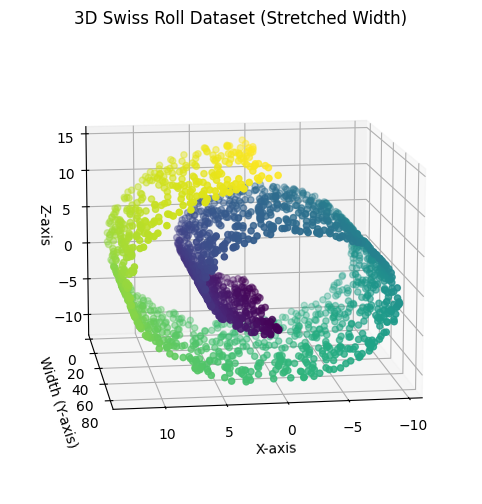

In [2]:
swissroll, color_var = make_swiss_roll(n_samples=2000, random_state=42)

# Stretch the width of the cylinder (Y-axis) so it becomes a primary harmonic
swissroll[:, 1] *= 4.0

# 1. Plot the Original 3D Swiss Roll
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Color points by their 1D unwrapped position (color_var)
ax.scatter(swissroll[:, 0], swissroll[:, 1], swissroll[:, 2], c=color_var, cmap=plt.cm.viridis)
ax.set_title("3D Swiss Roll Dataset (Stretched Width)")

# view angle
ax.view_init(elev=12, azim=82)

ax.set_xlabel("X-axis")
ax.set_ylabel("Width (Y-axis)")
ax.set_zlabel("Z-axis")
plt.show()

Running automatic spectral embedding...
Auto-selected epsilon (sparse BGH): 4.7619


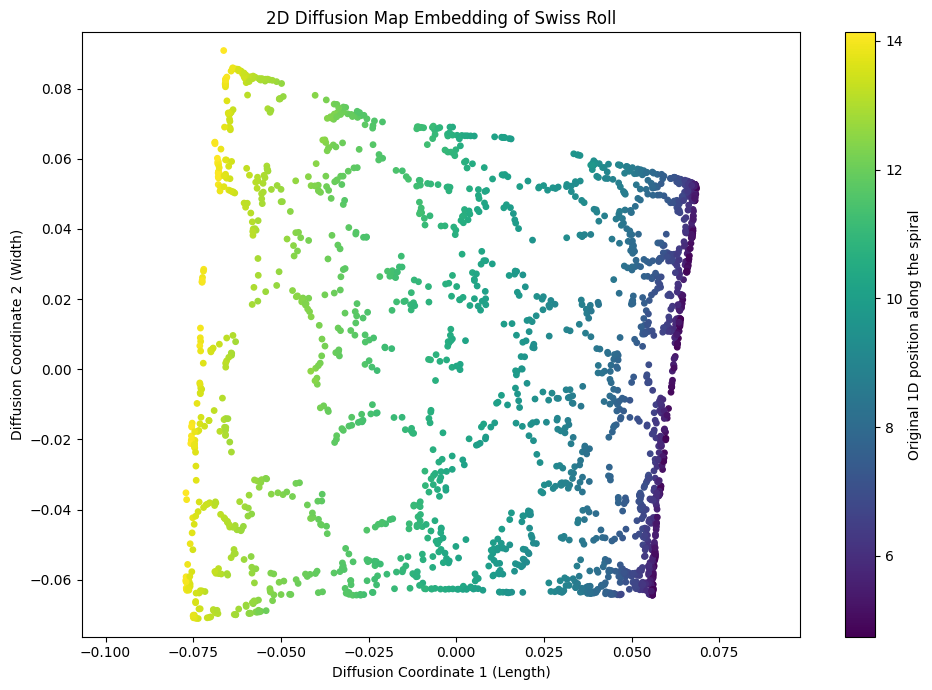

In [3]:
# 2. Run Diffusion Map on the dataset

print("Running automatic spectral embedding...")
embedding, eigval = diffmap(
    X=swissroll, 
    epsilon=None,     # Auto-calculate bandwidth
    method='auto',    # Automatically routes to sparse
    k=20,             # Keep k=20 for strong local connections
    alpha=1.0, 
    n_components=3, 
    t=1
)

# 3. Plot the 2D Mapped points with original colors
fig = plt.figure(figsize=(10, 7))

# Because we stretched the Y-axis above by 4.0, the first two eigenvectors 
# now naturally represent the "Length" and the "Width" of the unwrapped sheet!
plt.scatter(embedding[:, 0], embedding[:, 1], c=color_var, cmap=plt.cm.viridis, s=15)

plt.xlabel('Diffusion Coordinate 1 (Length)')
plt.ylabel('Diffusion Coordinate 2 (Width)')
plt.title('2D Diffusion Map Embedding of Swiss Roll')
plt.colorbar(label='Original 1D position along the spiral')
plt.axis('equal')

plt.tight_layout()
plt.show()

# Application: Human Activity Recognition (UCI HAR Dataset)

The UCI Human Activity Recognition (HAR) dataset contains data collected from 30 volunteers performing six basic activities (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS, SITTING, STANDING, LAYING) while wearing a smartphone (Samsung Galaxy S II) on their waist. The embedded accelerometer and gyroscope captured 3-axial linear acceleration and 3-axial angular velocity. 

**Goal:**
Our objective is to apply the Diffusion Map algorithm to this high-dimensional sensor data (561 features) to reduce its dimensionality to 2D or 3D. By doing so, we aim to uncover the underlying non-linear manifold of the data and visualize how well the distinct physical activities cluster together in the diffusion space.

In [4]:
import numpy as np
import os

# Load the UCI HAR dataset
base_dir = "../dataset/UCI HAR Dataset"

print("Loading UCI HAR dataset...")
# Load train set
X_train = np.loadtxt(os.path.join(base_dir, "train", "X_train.txt"))
y_train = np.loadtxt(os.path.join(base_dir, "train", "y_train.txt"), dtype=int)

# Load test set
X_test = np.loadtxt(os.path.join(base_dir, "test", "X_test.txt"))
y_test = np.loadtxt(os.path.join(base_dir, "test", "y_test.txt"), dtype=int)

# Load activity labels
with open(os.path.join(base_dir, "activity_labels.txt"), 'r') as f:
    activity_labels = [line.strip().split()[1] for line in f.readlines()]

print(f"Shape of training set: {X_train.shape}")
print(f"Shape of test set: {X_test.shape}")

Loading UCI HAR dataset...
Shape of training set: (7352, 561)
Shape of test set: (2947, 561)


Tabular preview of the raw 561-dimensional UCI HAR dataset:


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",Activity_ID,Activity_Name
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,5,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,5,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,5,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,5,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,5,STANDING


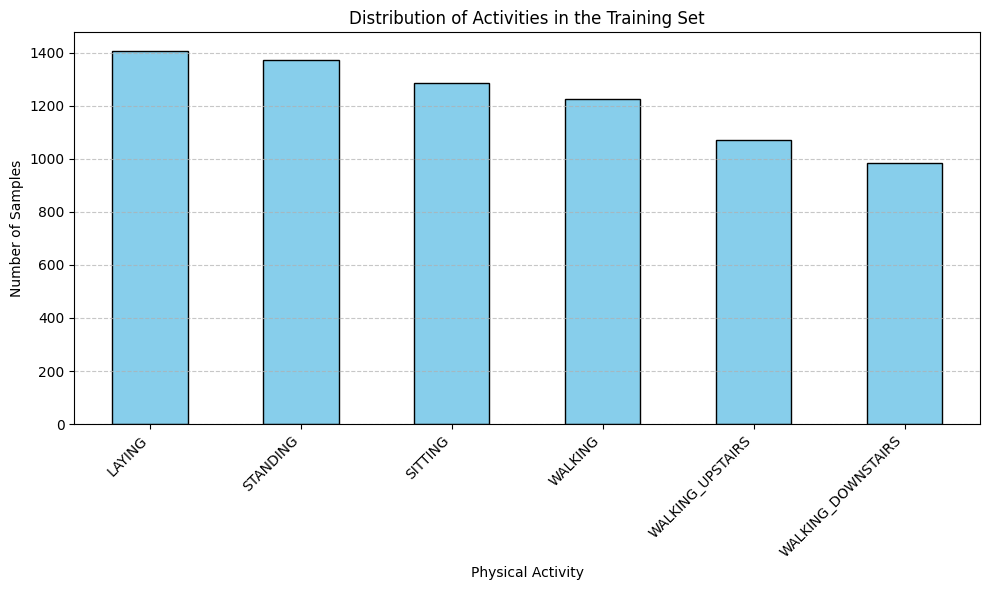

In [5]:
import pandas as pd
from IPython.display import display

# Load feature names to make the table descriptive
with open(os.path.join(base_dir, "features.txt"), 'r') as f:
    feature_names = [line.strip().split()[1] for line in f.readlines()]

# Create a full DataFrame with features and the target activity
df_train_full = pd.DataFrame(X_train, columns=feature_names)
df_train_full['Activity_ID'] = y_train
df_train_full['Activity_Name'] = df_train_full['Activity_ID'].map(lambda x: activity_labels[x-1])

print("Tabular preview of the raw 561-dimensional UCI HAR dataset:")
display(df_train_full.head())

# Let's visualize the distribution of activities in the training set
activity_counts = df_train_full['Activity_Name'].value_counts()

plt.figure(figsize=(10, 6))
activity_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Activities in the Training Set')
plt.xlabel('Physical Activity')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from helpers import bgh, nystrom_extension

# Bypass exhaustive cross-validation grid search to conserve computation.
# Set optimal model parameters identified from prior hyperparameter tuning.
best_params = {
    'k': 15,
    'n_components': 80,
    't': 1
}

In [7]:
# 1. Determine optimal kernel bandwidth (epsilon) using sparse BGH heuristic
final_epsilon = bgh(X_train, method='sparse', k=best_params['k'])

# 2. Extract non-linear eigenspace dimensions from the full training manifold
embedding_train, eigval_train = diffmap(
    X=X_train, 
    epsilon=final_epsilon,  
    method='sparse',  
    k=best_params['k'],             
    alpha=1.0, 
    n_components=best_params['n_components'],  
    t=best_params['t']
)

# 3. Project out-of-sample test instances via computationally efficient Nystrom approximation
embedding_test = nystrom_extension(X_test, X_train, embedding_train, eigval_train, final_epsilon, k=best_params['k'])

In [8]:
# 3. Train predictive Random Forest model strictly on the reduced continuous diffusion coordinates
clf_final = RandomForestClassifier(n_estimators=100, random_state=42)
clf_final.fit(embedding_train, y_train)

# Extrapolate validation target classification outcomes 
y_pred_final = clf_final.predict(embedding_test)

final_acc = accuracy_score(y_test, y_pred_final)

print("="*60)
print(f"Final Test classification using {best_params['n_components']} Diffusion Dimensions")
print("="*60)
print(classification_report(y_test, y_pred_final, target_names=activity_labels))
print(f"=> Random Forest Overall Test Set Accuracy: {final_acc*100:.2f}%")

Final Test classification using 80 Diffusion Dimensions
                    precision    recall  f1-score   support

           WALKING       0.88      0.98      0.93       496
  WALKING_UPSTAIRS       0.90      0.91      0.90       471
WALKING_DOWNSTAIRS       0.95      0.81      0.88       420
           SITTING       0.83      0.68      0.75       491
          STANDING       0.75      0.88      0.81       532
            LAYING       1.00      0.99      1.00       537

          accuracy                           0.88      2947
         macro avg       0.88      0.88      0.88      2947
      weighted avg       0.88      0.88      0.88      2947

=> Random Forest Overall Test Set Accuracy: 87.92%
